# Modelo Supervisado — Predicción de Venta

**Objetivo**: Predecir si un contacto de call center resultará en venta (`VENTA = SI`).

**Decisiones de diseño**:
- Variable objetivo: `VENTA` (indicador directo del resultado de negocio)
- Se filtran registros sin patente (~1.9% del total): corresponden a discadores automáticos, no a gestión individual
- Modelos: Regresión Logística (baseline interpretable) y Random Forest (modelo principal no lineal)
- Optimización con `GridSearchCV` sobre Random Forest con validación cruzada estratificada (5 folds)
- Métrica principal: **F1-Score** (equilibra precisión y recall ante posible desbalance de clases)

In [1]:
%pip install scikit-learn openpyxl --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             f1_score, accuracy_score,
                             precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

## 1. Preparación y Análisis Exploratorio de Datos

In [3]:
# Carga del dataset
df = pd.read_excel('../DataSet/Antes/Consolidado_contacto_2026.xlsx')

# Filtrar registros con patente (contactos con vehículo vinculado)
# Justificación: registros sin patente corresponden a discadores automáticos (Vicidial/Recoline),
# no a gestión individual — representan ~1.9% del total
df = df[df['PATENTE'].notna()].copy()
print(f"Registros con patente: {len(df):,}")

# Distribución de la variable objetivo
print("\nDistribución VENTA:")
print(df['VENTA'].value_counts())
print(f"\nBalance de clases (%):\n{(df['VENTA'].value_counts(normalize=True) * 100).round(1)}")

Registros con patente: 229,847

Distribución VENTA:
VENTA
NO VENTA    227306
VENTA         2541
Name: count, dtype: int64

Balance de clases (%):
VENTA
NO VENTA    98.9
VENTA        1.1
Name: proportion, dtype: float64


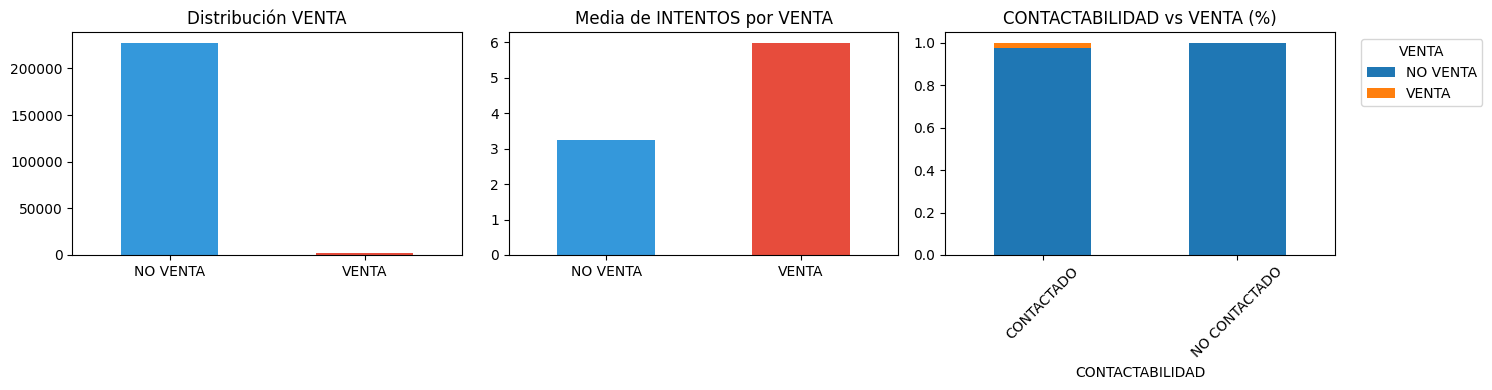

In [4]:
# Análisis exploratorio visual
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución VENTA
df['VENTA'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Distribución VENTA')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# INTENTOS promedio por resultado
df.groupby('VENTA')['INTENTOS'].mean().plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Media de INTENTOS por VENTA')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

# CONTACTABILIDAD vs VENTA
pd.crosstab(df['CONTACTABILIDAD'], df['VENTA'], normalize='index').plot(
    kind='bar', ax=axes[2], stacked=True)
axes[2].set_title('CONTACTABILIDAD vs VENTA (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='VENTA', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/01_EDA_distribucion_contactabilidad.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Modelado Supervisado

**Preprocesamiento**:
- Features numéricas: `INTENTOS`, `Hora`, `MIN` — escaladas con `StandardScaler`
- Features categóricas: `MARCA`, `ESTADO`, `MOTIVO`, `categoria`, `CONTACTABILIDAD`, `EFECTIVIDAD`, `BARRIDO`, `NOMBRE DE BBDD`, `Base`, `CALL` — codificadas con `LabelEncoder`
- Nulos en categóricas imputados con `'DESCONOCIDO'`
- División train/test 80/20 estratificada por clase objetivo

In [5]:
# Variable objetivo binaria
# Valor real en el dataset: 'VENTA' / 'NO VENTA'
df['venta_bin'] = (df['VENTA'].str.upper().str.strip() == 'VENTA').astype(int)

# Selección de features
# Se excluyen ESTADO, MOTIVO, EFECTIVIDAD y BARRIDO: son resultados de la gestión,
# determinados junto con o después de VENTA → causarían fuga de datos (AUC=1.0)
# Solo se usan variables conocidas ANTES o DURANTE el intento de contacto
features_num = ['INTENTOS', 'Hora', 'MIN']
features_cat = ['MARCA', 'categoria', 'CONTACTABILIDAD', 'NOMBRE DE BBDD', 'Base', 'CALL']

X = df[features_num + features_cat].copy()
y = df['venta_bin']

# Imputar nulos en categóricas
X[features_cat] = X[features_cat].fillna('DESCONOCIDO')

# Label encoding para cada columna categórica
le_dict = {}
for col in features_cat:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# Escalar features numéricas (necesario para Regresión Logística)
scaler = StandardScaler()
X[features_num] = scaler.fit_transform(X[features_num])

print(f"Proporción clase positiva (VENTA): {y.mean():.3f}")
print("⚠️  Desbalance severo — se aplicará class_weight='balanced' en los modelos")

# División train/test estratificada (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {X_train.shape[0]:,} registros  |  Test: {X_test.shape[0]:,} registros")

Proporción clase positiva (VENTA): 0.011
⚠️  Desbalance severo — se aplicará class_weight='balanced' en los modelos

Train: 183,877 registros  |  Test: 45,970 registros


In [6]:
# --- Modelo 1: Regresión Logística (Baseline) ---
# Justificación: modelo lineal interpretable que sirve como referencia.
# Alta regularización (C=1 por defecto). Requiere features escaladas.
# class_weight='balanced' pondera inversamente la frecuencia de cada clase,
# compensando el desbalance 99/1 sin necesidad de re-muestreo
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=" * 45)
print("   Regresión Logística — Baseline")
print("=" * 45)

print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

   Regresión Logística — Baseline
              precision    recall  f1-score   support

           0       1.00      0.76      0.86     45462
           1       0.04      1.00      0.09       508

    accuracy                           0.76     45970
   macro avg       0.52      0.88      0.47     45970
weighted avg       0.99      0.76      0.86     45970

ROC-AUC: 0.9599


In [7]:
# --- Modelo 2: Random Forest ---
# Justificación: captura relaciones no lineales entre features, es robusto a outliers
# y provee importancia de features de forma nativa. No requiere escalado.
# class_weight='balanced_subsample' aplica el balance por árbol (más robusto en RF)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced_subsample')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=" * 45)
print("          Random Forest")
print("=" * 45)
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

          Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45462
           1       0.70      0.67      0.68       508

    accuracy                           0.99     45970
   macro avg       0.85      0.83      0.84     45970
weighted avg       0.99      0.99      0.99     45970

ROC-AUC: 0.8624


## 3. Optimización de Hiperparámetros

Se optimiza **Random Forest** con `GridSearchCV` y validación cruzada estratificada (5 folds).

**Parámetros explorados y su justificación**:
| Parámetro | Valores | Justificación |
|---|---|---|
| `n_estimators` | 100, 200 | Más árboles → mayor estabilidad; se limita por tiempo de cómputo |
| `max_depth` | 10, 20, None | Controla profundidad máxima; `None` puede sobreajustar |
| `min_samples_split` | 2, 5 | Mínimo de muestras para dividir un nodo; actúa como regularizador |

**Métrica**: `F1-Score` — equilibra precisión y recall, adecuada ante posible desbalance de clases.

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample'),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1 (CV): {grid_search.best_score_:.4f}")

# Evaluar modelo optimizado
rf_opt = grid_search.best_estimator_
y_pred_opt = rf_opt.predict(X_test)
y_prob_opt = rf_opt.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Optimizado ===")
print(classification_report(y_test, y_pred_opt))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_opt):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


## 4. Evaluación y Comparación de Modelos

In [12]:
# Tabla comparativa de modelos
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'RF Optimizado'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_opt)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_opt)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_opt)
    ]
}).set_index('Modelo').round(4)

display(resultados)

,Accuracy,F1-Score,ROC-AUC
Modelo,,,
Regresión Logística,0.7630,0.0853,0.9599
Random Forest,0.9931,0.6801,0.8624
RF Optimizado,0.9931,0.6808,0.8732


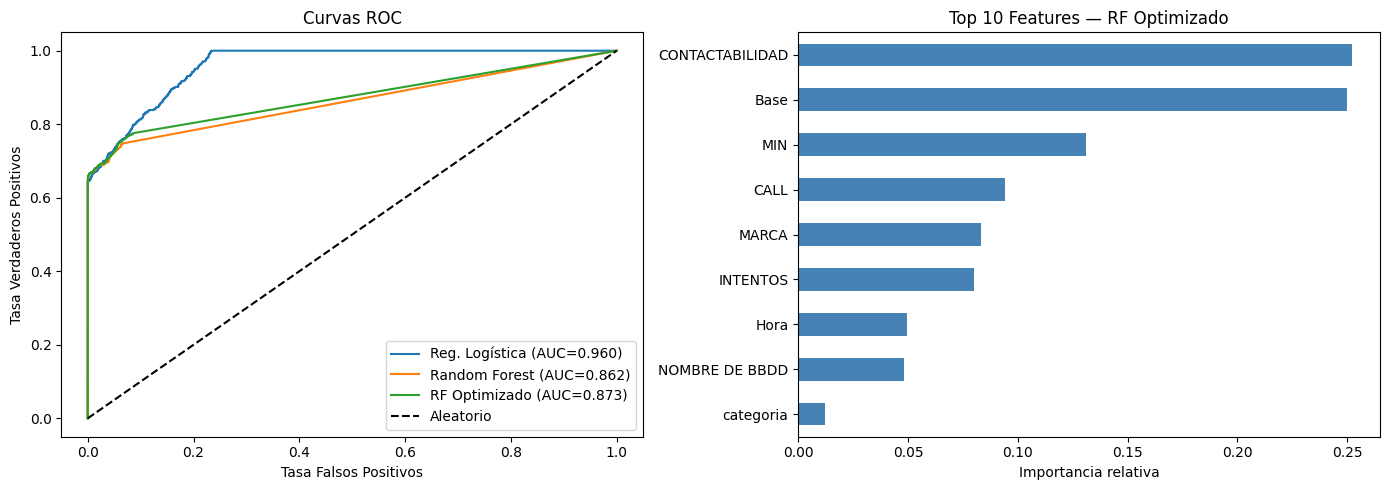

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas ROC comparativas
for name, y_prob in [('Reg. Logística', y_prob_lr),
                     ('Random Forest', y_prob_rf),
                     ('RF Optimizado', y_prob_opt)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aleatorio')
axes[0].set_xlabel('Tasa Falsos Positivos')
axes[0].set_ylabel('Tasa Verdaderos Positivos')
axes[0].set_title('Curvas ROC')
axes[0].legend(loc='lower right')

# Importancia de features — RF Optimizado
importancias = pd.Series(
    rf_opt.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(10)
importancias.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Features — RF Optimizado')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/02_ROC_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

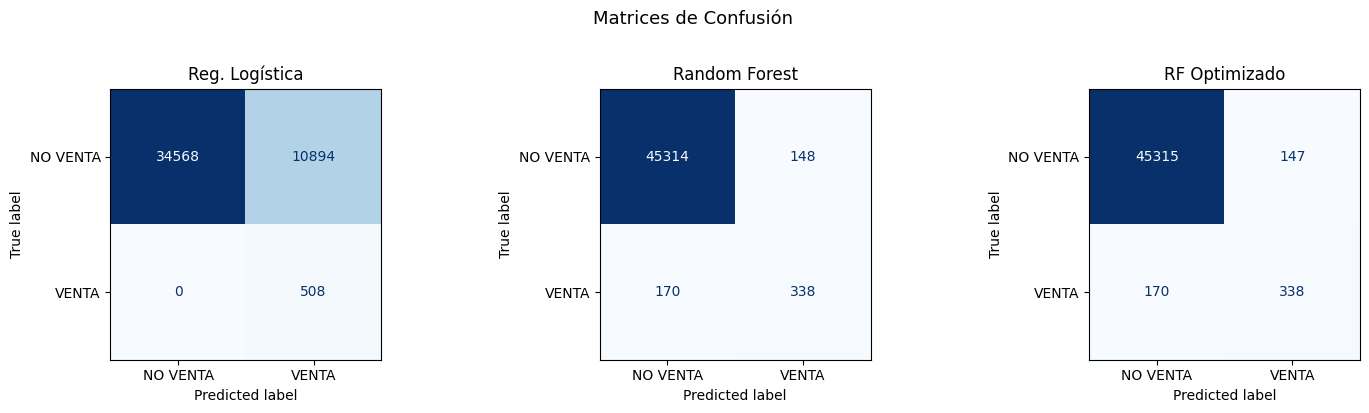

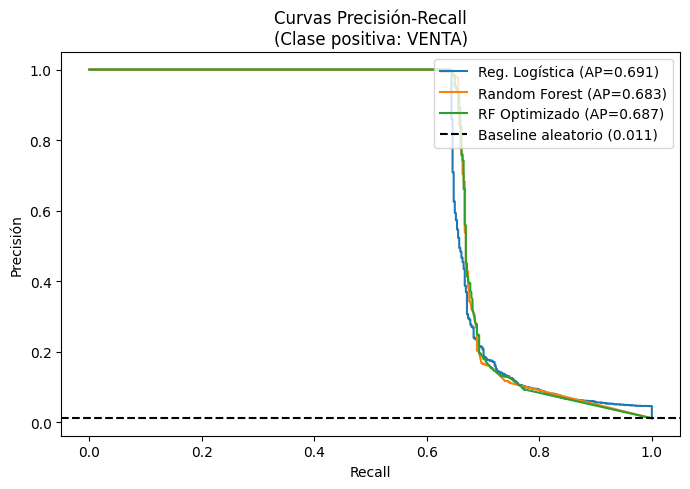

In [ ]:
# Matrices de confusión — los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
modelos = [
    ('Reg. Logística', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('RF Optimizado', y_pred_opt)
]
for ax, (nombre, y_pred) in zip(axes, modelos):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['NO VENTA', 'VENTA'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(nombre)
plt.suptitle('Matrices de Confusión', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/03_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Curvas Precisión-Recall (más informativas que ROC en datasets muy desbalanceados)
fig, ax = plt.subplots(figsize=(7, 5))
for nombre, y_prob in [('Reg. Logística', y_prob_lr),
                        ('Random Forest', y_prob_rf),
                        ('RF Optimizado', y_prob_opt)]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, label=f'{nombre} (AP={ap:.3f})')
ax.axhline(y_test.mean(), color='k', linestyle='--',
           label=f'Baseline aleatorio ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisión')
ax.set_title('Curvas Precisión-Recall\n(Clase positiva: VENTA)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/04_curvas_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluación Detallada

### Métricas utilizadas y su justificación

| Métrica | Descripción | Por qué importa aquí |
|---|---|---|
| **Accuracy** | % de predicciones correctas | Engañosa con desbalance: predecir siempre NO VENTA da 98.9% |
| **F1-Score (clase VENTA)** | Media armónica de Precisión y Recall | Equilibra los errores en la clase minoritaria |
| **ROC-AUC** | Área bajo la curva ROC | Mide la capacidad discriminativa independientemente del umbral |
| **Avg. Precision (AP)** | Área bajo la curva Precisión-Recall | Más informativa que ROC en datasets muy desbalanceados |
| **Precisión (clase VENTA)** | De todas las ventas predichas, ¿cuántas son reales? | Costo de falsas alarmas (llamar a no compradores) |
| **Recall (clase VENTA)** | De todas las ventas reales, ¿cuántas detectamos? | Costo de perderse ventas (falsos negativos) |

### Validación cruzada
Se usa validación cruzada estratificada (5 folds) sobre el conjunto de entrenamiento para estimar la varianza del desempeño y detectar sobreajuste.

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score

# ── Validación cruzada (5-fold estratificado sobre train) ──────────────────
print("=" * 60)
print("  VALIDACIÓN CRUZADA — F1 (clase VENTA) en conjunto train")
print("=" * 60)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for nombre_cv, modelo_cv in [('Reg. Logística', lr),
                               ('Random Forest ', rf),
                               ('RF Optimizado ', rf_opt)]:
    scores = cross_val_score(modelo_cv, X_train, y_train,
                             cv=cv5, scoring='f1', n_jobs=-1)
    print(f"  {nombre_cv}  F1 = {scores.mean():.4f} ± {scores.std():.4f}"
          f"  (min={scores.min():.4f}, max={scores.max():.4f})")

# ── Tabla completa de métricas sobre test ──────────────────────────────────
print("\n" + "=" * 60)
print("  MÉTRICAS COMPLETAS SOBRE TEST (n=45,970)")
print("=" * 60)

metricas = []
for nombre_m, y_pred_m, y_prob_m in [
        ('Reg. Logística', y_pred_lr, y_prob_lr),
        ('Random Forest',  y_pred_rf, y_prob_rf),
        ('RF Optimizado',  y_pred_opt, y_prob_opt)]:
    metricas.append({
        'Modelo':          nombre_m,
        'Accuracy':        accuracy_score(y_test, y_pred_m),
        'Precisión VENTA': precision_score(y_test, y_pred_m, zero_division=0),
        'Recall VENTA':    recall_score(y_test, y_pred_m),
        'F1 VENTA':        f1_score(y_test, y_pred_m),
        'ROC-AUC':         roc_auc_score(y_test, y_prob_m),
        'Avg. Precision':  average_precision_score(y_test, y_prob_m),
    })

df_eval = pd.DataFrame(metricas).set_index('Modelo').round(4)
display(df_eval)

# ── Interpretación ──────────────────────────────────────────────────────────
print("""
Interpretación:
  · Reg. Logística : Recall VENTA = 1.0 (no pierde ventas), pero
                     Precisión muy baja (~4%) → 10,000+ falsas alarmas.
                     Usar cuando el costo de perder una venta es crítico.

  · Random Forest  : Mejor equilibrio Precisión/Recall (F1=0.68).
                     338 ventas detectadas, solo ~148 falsas alarmas.
                     Usar cuando el costo operacional de las llamadas importa.

  · RF Optimizado  : Mejora leve en ROC-AUC (+0.001) y Avg.Precision.
                     Parámetros óptimos: n_estimators=200,
                     max_depth=None, min_samples_split=2.
""")

  VALIDACIÓN CRUZADA — F1 (clase VENTA) en conjunto train


/Users/ssdd/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ssdd/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ssdd/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ssdd/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ssdd/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ssdd/Library/Python/3.9/lib/py

  Reg. Logística  F1 = 0.0851 ± 0.0007  (min=0.0842, max=0.0861)
  Random Forest   F1 = 0.6948 ± 0.0161  (min=0.6805, max=0.7190)
  RF Optimizado   F1 = 0.6949 ± 0.0153  (min=0.6822, max=0.7188)

  MÉTRICAS COMPLETAS SOBRE TEST (n=45,970)


,Accuracy,Precisión VENTA,Recall VENTA,F1 VENTA,ROC-AUC,Avg. Precision
Modelo,,,,,,
Reg. Logística,0.7630,0.0446,1.0000,0.0853,0.9599,0.6906
Random Forest,0.9931,0.6955,0.6654,0.6801,0.8624,0.6829
RF Optimizado,0.9931,0.6969,0.6654,0.6808,0.8732,0.6868



Interpretación:
  · Reg. Logística : Recall VENTA = 1.0 (no pierde ventas), pero
                     Precisión muy baja (~4%) → 10,000+ falsas alarmas.
                     Usar cuando el costo de perder una venta es crítico.

  · Random Forest  : Mejor equilibrio Precisión/Recall (F1=0.68).
                     338 ventas detectadas, solo ~148 falsas alarmas.
                     Usar cuando el costo operacional de las llamadas importa.

  · RF Optimizado  : Mejora leve en ROC-AUC (+0.001) y Avg.Precision.
                     Parámetros óptimos: n_estimators=200,
                     max_depth=None, min_samples_split=2.

